In [ ]:
# ============================================================
#  LOOP ORDER (x0 outermost):
#    - For each x0:
#        * tune ell via pilot data (depends only on x0)
#        * for r = 1..R:
#            - sample ONE unlabeled set X_u^(r) (random; NOT shared across x0)
#            - split into two folds
#            - precompute m(X_u), bias(X_u)
#            - train/tune weights on X_u^(r) ONLY
#            - run B MC reps (resample labeled each time)
#        * aggregate metrics over ALL reps (R*B) and print final results
#        * save ONE row per x0 to CSV immediately (checkpointing)
#
#  DGP:
#      Y = m_true(X) + eps
#      f = Y + bias(X) + nu 
# ============================================================

import os
import csv
import numpy as np
import cupy as cp

from ppi_py import ppi_mean_ci, ppi_mean_pointestimate

from conditional_mean_functions import (
    select_logell_by_pilot_logo_cv,
    build_twofold_weights,
    ppci_conditional_mean_cf,
    ppci_conditional_mean_label_only_cf,
)

xp = cp
np.set_printoptions(precision=4, suppress=True)


# ============================================================
# 1) Ground-truth conditional mean on [0,1]^3
# ============================================================
def m_true_np(X_raw: np.ndarray) -> np.ndarray:
    x1, x2, x3 = X_raw[:, 0], X_raw[:, 1], X_raw[:, 2]
    return (
        np.sin(2 * np.pi * x1)
        + 0.6 * np.cos(2 * np.pi * x2)
        + 0.4 * np.sin(2 * np.pi * x3)
        + 0.25 * np.sin(2 * np.pi * (x1 + x2))
    )


def bias_fn_np(X_raw: np.ndarray, bias_strength: float) -> np.ndarray:
    x1, x2, x3 = X_raw[:, 0], X_raw[:, 1], X_raw[:, 2]
    b = (x1 - 0.5) + 0.5 * np.sin(4 * np.pi * x2) - 0.3 * (x3 - 0.5)
    return bias_strength * b


# ============================================================
# 2) Fixed scaling for kernel/localization (Unif([0,1]) pop stats)
# ============================================================
def standardize_unif01(X_raw: np.ndarray) -> np.ndarray:
    mu = 0.5
    sd = 1.0 / np.sqrt(12.0)  # ~0.288675
    return (X_raw - mu) / sd


# ============================================================
# 3) x0 list
# ============================================================
def make_x0_grid(low=0.70, high=0.85, num=5):
    vals = np.linspace(low, high, num)
    x0_list = []
    for a in vals:
        for b in vals:
            for c in vals:
                x0_list.append(np.array([a, b, c], dtype=float))
    return x0_list


# ============================================================
# 4) Helper: ddof=1 std from sums
# ============================================================
def std_ddof1_from_sums(sum_x: float, sum_x2: float, n: int) -> float:
    if n <= 1:
        return 0.0
    var = (sum_x2 - (sum_x * sum_x) / n) / (n - 1)
    return float(np.sqrt(max(var, 0.0)))


# ============================================================
# 5) Helper: tune ell for a fixed x0 (pilot-only)
# ============================================================
def tune_ell_for_x0(
    x0_raw: np.ndarray,
    X_pilot_scaled: np.ndarray,
    Y_pilot: np.ndarray,
    LOGELL_grid_size: int,
    c_min: float,
    c_max: float,
):
    x0_raw = np.asarray(x0_raw, dtype=float).ravel()
    x0_scaled = standardize_unif01(x0_raw.reshape(1, -1))[0]

    theta0 = float(m_true_np(x0_raw.reshape(1, 3))[0])

    d_pilot = np.linalg.norm(X_pilot_scaled - x0_scaled.reshape(1, 3), axis=1)
    ell0_hat = float(np.median(d_pilot))
    ell0_hat = max(1e-8, ell0_hat)

    ell_low = max(1e-8, c_min * ell0_hat)
    ell_high = c_max * ell0_hat

    LOGELL_grid_local = np.linspace(np.log(ell_low), np.log(ell_high), int(LOGELL_grid_size))
    group_labels = np.arange(X_pilot_scaled.shape[0], dtype=int)  # LOOCV

    X_pilot_gpu = cp.asarray(X_pilot_scaled)
    Y_pilot_gpu = cp.asarray(Y_pilot)

    ell_star, _ = select_logell_by_pilot_logo_cv(
        LOGELL_grid=LOGELL_grid_local,
        X_pilot=X_pilot_gpu,
        Y_pilot=Y_pilot_gpu,
        group_labels=group_labels,
    )

    return {
        "x0_scaled": x0_scaled,
        "theta0": theta0,
        "ell0_hat": ell0_hat,
        "ell_low": ell_low,
        "ell_high": ell_high,
        "ell_star": float(ell_star),
    }


# ============================================================
# 6) CSV writer
# ============================================================
def write_results_to_csv(results_list, csv_path):
    if len(results_list) == 0:
        raise ValueError("results_list is empty; nothing to write.")
    fieldnames = list(results_list[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results_list:
            writer.writerow(row)
    print(f"\n[Saved Checkpoint] {csv_path}")


# ============================================================
# 7) Main
# ============================================================
if __name__ == "__main__":
    GPU_ID = 3
    cp.cuda.Device(GPU_ID).use()

    # --------------------------
    # Global config
    # --------------------------
    seed_data = 2025
    seed_split = 2026

    R = 5
    B = 200

    n_label = 200
    n_pilot = 200

    N = 10000  # unlabeled size per r (per x0 per r)

    sigma_eps = 2.0
    sigma_f = 1.2
    bias_strength = 0.2

    alpha = 0.05
    z_alpha = 1.96

    lam_grid = np.logspace(np.log10(0.1 / n_label), np.log10(10.0 / n_label), 100)

    LOGELL_grid_size = 50
    c_min = 0.01
    c_max = 0.08

    x0_list = make_x0_grid(low=0.70, high=0.85, num=10)

    # --------------------------
    # Pilot data (fixed once)
    # --------------------------
    rng0 = np.random.default_rng(seed_data)
    X_pilot_raw = rng0.uniform(0.0, 1.0, size=(n_pilot, 3))
    eps_pilot = rng0.normal(0.0, sigma_eps, size=n_pilot)
    Y_pilot = m_true_np(X_pilot_raw) + eps_pilot
    X_pilot_scaled = standardize_unif01(X_pilot_raw)

    # --------------------------
    # Outer loop over x0 (FINAL aggregation over R*B)
    # --------------------------
    all_rows = []
    total_reps = int(R * B)

    # Define output CSV path
    save_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, "simu_ppci_mean_results.csv")

    for j, x0_raw in enumerate(x0_list, 1):
        print("\n" + "=" * 80)
        print(f"[x0 #{j}/{len(x0_list)}] x0 = {x0_raw}  (aggregating over R*B = {total_reps})")
        print("=" * 80)

        # Tune ell once for this x0
        tune = tune_ell_for_x0(
            x0_raw=x0_raw,
            X_pilot_scaled=X_pilot_scaled,
            Y_pilot=Y_pilot,
            LOGELL_grid_size=LOGELL_grid_size,
            c_min=c_min,
            c_max=c_max,
        )

        x0_scaled = tune["x0_scaled"]
        theta0 = tune["theta0"]
        ell0_hat = tune["ell0_hat"]
        ell_low = tune["ell_low"]
        ell_high = tune["ell_high"]
        ell_star = tune["ell_star"]

        # Accumulators over ALL (r,b)
        # PPCI
        sum_th_ppci = 0.0
        sum_sqerr_ppci = 0.0
        sum_cov_ppci = 0.0
        sum_width_ppci = 0.0
        sum_s2_Ymf = 0.0
        sum_s2_Ymf2 = 0.0
        sum_s2_f = 0.0
        sum_s2_f2 = 0.0

        # LO
        sum_th_lo = 0.0
        sum_sqerr_lo = 0.0
        sum_cov_lo = 0.0
        sum_width_lo = 0.0
        sum_s2_Y = 0.0
        sum_s2_Y2 = 0.0

        # PPI
        sum_th_ppi = 0.0
        sum_sqerr_ppi = 0.0
        sum_cov_ppi = 0.0
        sum_width_ppi = 0.0

        # Diagnostics averaged over r
        sum_lam1 = 0.0
        sum_lam2 = 0.0
        sum_den_u = 0.0

        # --------------------------
        # Loop over r (sample a fresh Xu, NOT shared across x0)
        # --------------------------
        for r in range(1, R + 1):
            # Separate RNG stream for Xu so it's independent of labeled RNG
            rng_xu = np.random.default_rng(seed_split + 2_000_000 * j + 20_000 * r)

            X_u_raw = rng_xu.uniform(0.0, 1.0, size=(N, 3))
            perm = rng_xu.permutation(N)
            half = N // 2
            idx_fold1 = perm[:half]
            idx_fold2 = perm[half:]

            # Precompute once per (x0, r)
            m_u = m_true_np(X_u_raw)
            b_u = bias_fn_np(X_u_raw, bias_strength)

            # Train/tune two-fold weights on unlabeled ONLY
            X_u_scaled = standardize_unif01(X_u_raw)
            X_u_gpu = cp.asarray(X_u_scaled)

            w1_hat, w2_hat, w_oof_u, den_u, lam1, lam2 = build_twofold_weights(
                X_u=X_u_gpu,
                x0=x0_scaled,
                ell=ell_star,
                lam_grid=lam_grid,
                idx_fold1=idx_fold1,
                idx_fold2=idx_fold2,
                make_plot=False,
            )

            sum_lam1 += float(lam1)
            sum_lam2 += float(lam2)
            sum_den_u += float(den_u)

            # Labeled RNG (independent stream)
            rng_inner = np.random.default_rng(seed_split + 1_000_000 * j + 10_000 * r)

            for _ in range(B):
                # -------- Labeled draw --------
                X_l_raw = rng_inner.uniform(0.0, 1.0, size=(n_label, 3))
                m_l = m_true_np(X_l_raw)
                b_l = bias_fn_np(X_l_raw, bias_strength)

                eps_l = rng_inner.normal(0.0, sigma_eps, size=n_label)
                nu_l = rng_inner.normal(0.0, sigma_f, size=n_label)

                Y_l_cpu = m_l + eps_l
                # The predictor targets Y directly (absorbing high-dim noise/variance)
                f_l_cpu = Y_l_cpu + b_l + nu_l

                # -------- Unlabeled predictor outputs on THIS Xu --------
                eps_u = rng_inner.normal(0.0, sigma_eps, size=N)
                nu_u = rng_inner.normal(0.0, sigma_f, size=N)
                # The latent Y_u would be (m_u + eps_u). The predictor captures it.
                f_u_cpu = (m_u + eps_u) + b_u + nu_u

                # -------- Move to GPU --------
                X_l_scaled = standardize_unif01(X_l_raw)
                X_l = cp.asarray(X_l_scaled)
                Y_l = cp.asarray(Y_l_cpu)
                f_l = cp.asarray(f_l_cpu)
                f_u = cp.asarray(f_u_cpu)

                # --- PPCI ---
                th, se, (lo, up), ex = ppci_conditional_mean_cf(
                    X_l=X_l, Y_l=Y_l, f_l=f_l, f_u=f_u,
                    w1_hat=w1_hat, w2_hat=w2_hat, w_oof_u=w_oof_u,
                    z_alpha=z_alpha, return_extras=True
                )
                th = float(th)
                cov = float(lo <= theta0 <= up)
                width = float(up - lo)

                sum_th_ppci += th
                sum_sqerr_ppci += (th - theta0) ** 2
                sum_cov_ppci += cov
                sum_width_ppci += width

                s2_y_m_f = float(ex["sigma2_Y_minus_f"])
                s2_fv = float(ex["sigma2_f"])
                sum_s2_Ymf += s2_y_m_f
                sum_s2_Ymf2 += s2_y_m_f ** 2
                sum_s2_f += s2_fv
                sum_s2_f2 += s2_fv ** 2

                # --- LO ---
                th2, se2, (lo2, up2), ex2 = ppci_conditional_mean_label_only_cf(
                    X_l=X_l, Y_l=Y_l, w1_hat=w1_hat, w2_hat=w2_hat,
                    z_alpha=z_alpha, return_extras=True, denom_floor=1e-10
                )
                th2 = float(th2)
                cov2 = float(lo2 <= theta0 <= up2)
                width2 = float(up2 - lo2)

                sum_th_lo += th2
                sum_sqerr_lo += (th2 - theta0) ** 2
                sum_cov_lo += cov2
                sum_width_lo += width2

                s2y = float(ex2["sigma2_Y"])
                sum_s2_Y += s2y
                sum_s2_Y2 += s2y ** 2

                # --- PPI ---
                Y_l_cpu2 = cp.asnumpy(Y_l).ravel()
                f_l_cpu2 = cp.asnumpy(f_l).ravel()
                f_u_cpu2 = cp.asnumpy(f_u).ravel()

                ppi_lo, ppi_up = ppi_mean_ci(Y_l_cpu2, f_l_cpu2, f_u_cpu2, alpha=alpha)
                ppi_th = float(ppi_mean_pointestimate(Y_l_cpu2, f_l_cpu2, f_u_cpu2))

                cov3 = float(ppi_lo <= theta0 <= ppi_up)
                width3 = float(ppi_up - ppi_lo)

                sum_th_ppi += ppi_th
                sum_sqerr_ppi += (ppi_th - theta0) ** 2
                sum_cov_ppi += cov3
                sum_width_ppi += width3

        # --------------------------
        # Final aggregation over ALL reps = R*B
        # --------------------------
        PPCI_theta_mean = sum_th_ppci / total_reps
        PPCI_theta_rmse = float(np.sqrt(sum_sqerr_ppci / total_reps))
        PPCI_coverage = sum_cov_ppci / total_reps
        PPCI_avg_ci_width = sum_width_ppci / total_reps

        PPCI_sigma2_Y_minus_f_mean = sum_s2_Ymf / total_reps
        PPCI_sigma2_f_mean = sum_s2_f / total_reps
        PPCI_sigma2_Y_minus_f_std = std_ddof1_from_sums(sum_s2_Ymf, sum_s2_Ymf2, total_reps)
        PPCI_sigma2_f_std = std_ddof1_from_sums(sum_s2_f, sum_s2_f2, total_reps)

        LO_theta_mean = sum_th_lo / total_reps
        LO_theta_rmse = float(np.sqrt(sum_sqerr_lo / total_reps))
        LO_coverage = sum_cov_lo / total_reps
        LO_avg_ci_width = sum_width_lo / total_reps
        LO_sigma2_Y_mean = sum_s2_Y / total_reps
        LO_sigma2_Y_std = std_ddof1_from_sums(sum_s2_Y, sum_s2_Y2, total_reps)

        PPI_theta_mean = sum_th_ppi / total_reps
        PPI_theta_rmse = float(np.sqrt(sum_sqerr_ppi / total_reps))
        PPI_coverage = sum_cov_ppi / total_reps
        PPI_avg_ci_width = sum_width_ppi / total_reps

        # Mean diagnostics over r
        lambda_1_mean = sum_lam1 / R
        lambda_2_mean = sum_lam2 / R
        den_u_mean = sum_den_u / R
        lambda_hat = 0.5 * (lambda_1_mean + lambda_2_mean)

        out = {
            # x0 / truth
            "x0_1": float(x0_raw[0]),
            "x0_2": float(x0_raw[1]),
            "x0_3": float(x0_raw[2]),
            "theta0": float(theta0),

            # tuning diagnostics
            "c_min": float(c_min),
            "c_max": float(c_max),
            "ell0_hat": float(ell0_hat),
            "ell_low": float(ell_low),
            "ell_high": float(ell_high),
            "ell_star": float(ell_star),

            # lambda diagnostics (means over r)
            "lambda_hat": float(lambda_hat),
            "lambda_1": float(lambda_1_mean),
            "lambda_2": float(lambda_2_mean),
            "den_u": float(den_u_mean),

            # budgets
            "B": int(total_reps),  # aggregated over R*B
            "n_label": int(n_label),
            "n_pilot": int(n_pilot),
            "N_unlab_total": int(N),
            "N_t_full": int(N),
            "N_use": int(N),
            "N": int(N),

            # PPCI
            "PPCI_theta_mean": float(PPCI_theta_mean),
            "PPCI_theta_rmse": float(PPCI_theta_rmse),
            "PPCI_coverage": float(PPCI_coverage),
            "PPCI_avg_ci_width": float(PPCI_avg_ci_width),

            "PPCI_sigma2_Y_minus_f_mean": float(PPCI_sigma2_Y_minus_f_mean),
            "PPCI_sigma2_f_mean": float(PPCI_sigma2_f_mean),
            "PPCI_sigma2_Y_minus_f_std": float(PPCI_sigma2_Y_minus_f_std),
            "PPCI_sigma2_f_std": float(PPCI_sigma2_f_std),

            # legacy alias for matching previous CSV schema
            "PPCI_sigma2_Y_minus_A_mean": float(PPCI_sigma2_Y_minus_f_mean),
            "PPCI_sigma2_A_mean": float(PPCI_sigma2_f_mean),
            "PPCI_sigma2_Y_minus_A_std": float(PPCI_sigma2_Y_minus_f_std),
            "PPCI_sigma2_A_std": float(PPCI_sigma2_f_std),

            # LO
            "LO_theta_mean": float(LO_theta_mean),
            "LO_theta_rmse": float(LO_theta_rmse),
            "LO_coverage": float(LO_coverage),
            "LO_avg_ci_width": float(LO_avg_ci_width),
            "LO_sigma2_Y_mean": float(LO_sigma2_Y_mean),
            "LO_sigma2_Y_std": float(LO_sigma2_Y_std),

            # PPI
            "PPI_theta_mean": float(PPI_theta_mean),
            "PPI_theta_rmse": float(PPI_theta_rmse),
            "PPI_coverage": float(PPI_coverage),
            "PPI_avg_ci_width": float(PPI_avg_ci_width),
        }

        all_rows.append(out)

        # Print outputs
        print(
            f"theta0={out['theta0']:.6f}  "
            f"ell_star={out['ell_star']:.4f}  "
            f"lambda_1(mean)={out['lambda_1']:.3g}  lambda_2(mean)={out['lambda_2']:.3g}  "
            f"den_u(mean)={out['den_u']:.4g}"
        )
        print(
            "PPCI (final over R*B): "
            f"rmse={out['PPCI_theta_rmse']:.6f}  cov={out['PPCI_coverage']:.3f}  "
            f"width={out['PPCI_avg_ci_width']:.6f}  "
            f"s2_Ymf={out['PPCI_sigma2_Y_minus_f_mean']:.4f}  "
            f"s2_f={out['PPCI_sigma2_f_mean']:.4f}"
        )
        print(
            "LO   (final over R*B): "
            f"rmse={out['LO_theta_rmse']:.6f}  cov={out['LO_coverage']:.3f}  "
            f"width={out['LO_avg_ci_width']:.6f}  "
            f"s2_Y={out['LO_sigma2_Y_mean']:.4f}"
        )
        print(
            "PPI  (final over R*B): "
            f"rmse={out['PPI_theta_rmse']:.6f}  cov={out['PPI_coverage']:.3f}  "
            f"width={out['PPI_avg_ci_width']:.6f}"
        )

        # ==========================================================
        # Checkpointing: Save CSV directly inside the x0 loop
        # ==========================================================
        write_results_to_csv(all_rows, csv_path)

    print("\nDone. All x0 processed and safely saved!")

✅ Saved: simu_mean_rmse_coverage_width.pdf


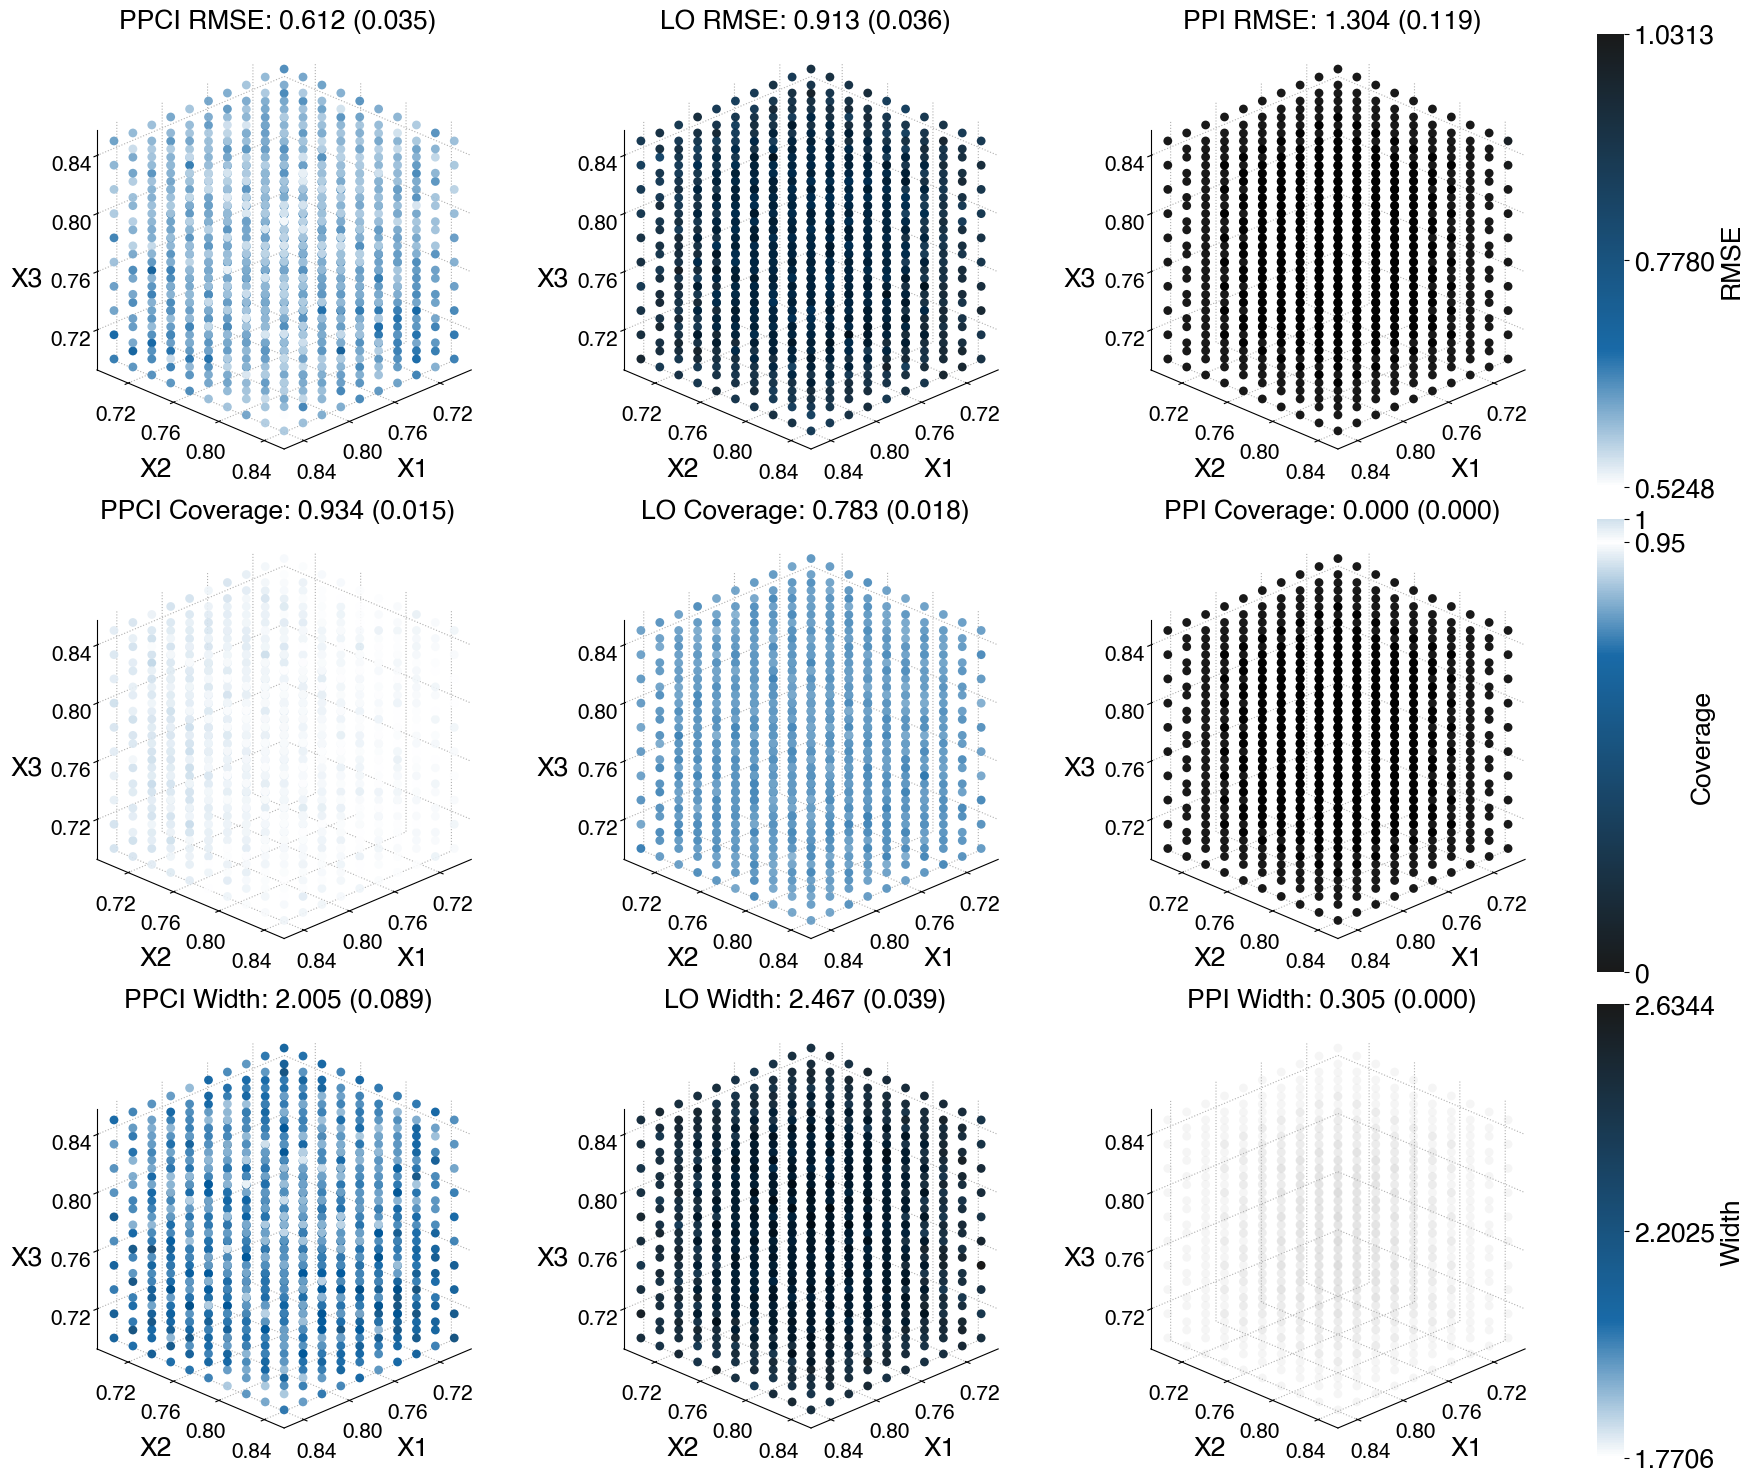

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.font_manager as fm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# =============================
# 0. Font & style
# =============================
FONT_SIZE = 19
font_path = "/home/ysui8/yangsuienv/Helvetica.ttf"

if os.path.exists(font_path):
    try:
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        mpl.rcParams["font.family"] = prop.get_name()
    except Exception as e:
        print("⚠️ Helvetica load failed; using default font.", e)

mpl.rcParams["font.size"] = FONT_SIZE


# =============================
# 1. Load data (NEW mean setting output)
# =============================
csv_path = "./results/simu_ppci_mean_results.csv"

def _pick_col(df, candidates):
    """Return the first existing column name among candidates, else raise."""
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Cannot find any of these columns: {candidates}")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # x-coordinates (new schema uses x0_1,x0_2,x0_3)
    x1_col = _pick_col(df, ["x0_1", "x1"])
    x2_col = _pick_col(df, ["x0_2", "x2"])
    x3_col = _pick_col(df, ["x0_3", "x3"])

    x1 = df[x1_col].values.astype(float)
    x2 = df[x2_col].values.astype(float)
    x3 = df[x3_col].values.astype(float)

    # metric columns (new schema; keep fallback to legacy alias if needed)
    col_cov = {
        "PPCI": _pick_col(df, ["PPCI_coverage"]),
        "LO":   _pick_col(df, ["LO_coverage", "PPCI_LO_coverage"]),
        "PPI":  _pick_col(df, ["PPI_coverage"]),
    }
    col_rmse = {
        "PPCI": _pick_col(df, ["PPCI_theta_rmse"]),
        "LO":   _pick_col(df, ["LO_theta_rmse", "PPCI_LO_theta_rmse"]),
        "PPI":  _pick_col(df, ["PPI_theta_rmse"]),
    }
    col_wid = {
        "PPCI": _pick_col(df, ["PPCI_avg_ci_width"]),
        "LO":   _pick_col(df, ["LO_avg_ci_width", "PPCI_LO_avg_ci_width"]),
        "PPI":  _pick_col(df, ["PPI_avg_ci_width"]),
    }

    coverage = {k: df[v].values.astype(float) for k, v in col_cov.items()}
    rmse = {k: df[v].values.astype(float) for k, v in col_rmse.items()}
    width = {k: df[v].values.astype(float) for k, v in col_wid.items()}

else:
    print("⚠️ Debug mode: generate random data (no CSV found)")
    n = 10
    x = np.linspace(0.70, 0.85, n)
    X1, X2, X3 = np.meshgrid(x, x, x)
    x1, x2, x3 = X1.flatten(), X2.flatten(), X3.flatten()

    coverage = {
        "PPCI": np.clip(np.random.normal(0.95, 0.02, size=len(x1)), 0, 1),
        "LO":   np.clip(np.random.normal(0.93, 0.03, size=len(x1)), 0, 1),
        "PPI":  np.clip(np.random.normal(0.75, 0.10, size=len(x1)), 0, 1),
    }
    rmse = {
        "PPCI": np.abs(np.random.normal(0.7, 0.1, size=len(x1))),
        "LO":   np.abs(np.random.normal(0.9, 0.15, size=len(x1))),
        "PPI":  np.abs(np.random.normal(1.4, 0.25, size=len(x1))),
    }
    width = {
        "PPCI": np.abs(np.random.normal(1.8, 0.2, size=len(x1))),
        "LO":   np.abs(np.random.normal(2.6, 0.3, size=len(x1))),
        "PPI":  np.abs(np.random.normal(0.8, 0.15, size=len(x1))),
    }


# =============================
# 1.5 Axis ranges (auto padding)
# =============================
def padded_lim(arr, pad_frac=0.05):
    lo, hi = float(np.min(arr)), float(np.max(arr))
    if hi <= lo:
        return [lo - 1e-6, hi + 1e-6]
    pad = pad_frac * (hi - lo)
    return [lo - pad, hi + pad]

xlim = padded_lim(x1, 0.05)
ylim = padded_lim(x2, 0.05)
zlim = padded_lim(x3, 0.05)


# =============================
# 2. Colormaps (same as your old design)
# =============================
color_blue = "#005a9e"
color_white = "#ffffff"
color_black = "#000000"

rgb_blue = mcolors.hex2color(color_blue)
rgb_white = mcolors.hex2color(color_white)
rgb_black = mcolors.hex2color(color_black)

saturation_point = 0.30

# (A) Coverage colormap: lightest at 0.95
ratio_sym = 0.05 / (saturation_point - 0.05)
color_at_1 = (
    rgb_white[0] * (1 - ratio_sym) + rgb_blue[0] * ratio_sym,
    rgb_white[1] * (1 - ratio_sym) + rgb_blue[1] * ratio_sym,
    rgb_white[2] * (1 - ratio_sym) + rgb_blue[2] * ratio_sym,
)
coverage_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_coverage_cmap_sym",
    [
        (0.00, rgb_black),
        (1.0 - saturation_point, rgb_blue),  # around 0.70
        (0.95, rgb_white),
        (1.00, color_at_1),
    ],
)
coverage_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

# (B) Sequential colormap for RMSE / Width: small -> light, large -> dark
seq_cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_seq_cmap",
    [
        (0.00, rgb_white),
        (saturation_point, rgb_blue),
        (1.00, rgb_black),
    ],
)

# =============================
# Key: RMSE/Width scale only from PPCI & LO (ignore PPI)
# =============================
scale_methods = ["PPCI", "LO"]

rmse_vmin = float(min(np.min(rmse[m]) for m in scale_methods))
rmse_vmax = float(max(np.max(rmse[m]) for m in scale_methods))
width_vmin = float(min(np.min(width[m]) for m in scale_methods))
width_vmax = float(max(np.max(width[m]) for m in scale_methods))

if rmse_vmax <= rmse_vmin:
    rmse_vmax = rmse_vmin + 1e-12
if width_vmax <= width_vmin:
    width_vmax = width_vmin + 1e-12

rmse_norm = mcolors.Normalize(vmin=rmse_vmin, vmax=rmse_vmax, clip=True)
width_norm = mcolors.Normalize(vmin=width_vmin, vmax=width_vmax, clip=True)


# =============================
# 3. Plot: 3 rows x 3 cols
#   Row 1: RMSE
#   Row 2: Coverage
#   Row 3: Width
# =============================
fig = plt.figure(figsize=(18, 16), facecolor="white")

method_order = ["PPCI", "LO", "PPI"]
grid_style = {"color": "#B0B0B0", "linestyle": ":", "linewidth": 0.8}

top_margin = 0.95
bottom_margin = 0.06
left_margin = 0.06
right_margin = 0.90
wspace = 0.15
hspace = 0.10

def style_3d(ax):
    ax.set_proj_type("ortho")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=25, azim=45)

    ax.set_facecolor("white")
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    ax.xaxis._axinfo["grid"].update(grid_style)
    ax.yaxis._axinfo["grid"].update(grid_style)
    ax.zaxis._axinfo["grid"].update(grid_style)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)

    locator = plt.MaxNLocator(nbins=4)
    ax.xaxis.set_major_locator(locator)
    ax.yaxis.set_major_locator(locator)
    ax.zaxis.set_major_locator(locator)

    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE - 4)

    ax.set_xlabel("X1", fontsize=FONT_SIZE, labelpad=10)
    ax.set_ylabel("X2", fontsize=FONT_SIZE, labelpad=10)
    ax.text2D(
        -0.03, 0.45, "X3",
        transform=ax.transAxes,
        fontsize=FONT_SIZE,
        va="center", ha="right",
    )

gs = fig.add_gridspec(
    nrows=3, ncols=3,
    left=left_margin, right=right_margin,
    top=top_margin, bottom=bottom_margin,
    wspace=wspace, hspace=hspace
)

img_rmse = None
img_cov = None
img_wid = None

PPI_GRAY = "#B0B0B0"  # gray dots for PPI width panel

for c, method in enumerate(method_order):
    # Row 1: RMSE
    ax1 = fig.add_subplot(gs[0, c], projection="3d")
    style_3d(ax1)
    vals = rmse[method]
    mu, sd = float(np.mean(vals)), float(np.std(vals))
    ax1.set_title(f"{method} RMSE: {mu:.3f} ({sd:.3f})", fontsize=FONT_SIZE, pad=-10)
    img_rmse = ax1.scatter(
        x1, x2, x3,
        c=vals, cmap=seq_cmap, norm=rmse_norm,
        s=40, edgecolors="black", linewidth=0, alpha=0.9
    )

    # Row 2: Coverage
    ax2 = fig.add_subplot(gs[1, c], projection="3d")
    style_3d(ax2)
    vals = coverage[method]
    mu, sd = float(np.mean(vals)), float(np.std(vals))
    ax2.set_title(f"{method} Coverage: {mu:.3f} ({sd:.3f})", fontsize=FONT_SIZE, pad=-10)
    img_cov = ax2.scatter(
        x1, x2, x3,
        c=vals, cmap=coverage_cmap, norm=coverage_norm,
        s=40, edgecolors="black", linewidth=0, alpha=0.9
    )

    # Row 3: Width
    ax3 = fig.add_subplot(gs[2, c], projection="3d")
    style_3d(ax3)
    vals = width[method]
    mu, sd = float(np.mean(vals)), float(np.std(vals))
    ax3.set_title(f"{method} Width: {mu:.3f} ({sd:.3f})", fontsize=FONT_SIZE, pad=-10)

    if method == "PPI":
        # PPI width panel: gray, very transparent
        ax3.scatter(
            x1, x2, x3,
            c=PPI_GRAY,
            s=40, edgecolors="black", linewidth=0, alpha=0.12
        )
        # do NOT overwrite img_wid (keep colorbar scale based on PPCI/LO)
    else:
        img_wid = ax3.scatter(
            x1, x2, x3,
            c=vals, cmap=seq_cmap, norm=width_norm,
            s=40, edgecolors="black", linewidth=0, alpha=0.9
        )

# =============================
# 4. Three colorbars (one per row)
# =============================
cbar_left = 0.92
cbar_width = 0.015
gap = 0.02
total_h = top_margin - bottom_margin
row_h = (total_h - 2 * gap) / 3.0

# Row 1 (RMSE): start from rmse_vmin (NOT 0)
y0_rmse = top_margin - row_h
cax1 = fig.add_axes([cbar_left, y0_rmse, cbar_width, row_h])
cb1 = fig.colorbar(img_rmse, cax=cax1)
cb1.outline.set_visible(False)
cb1.set_ticks([rmse_vmin, 0.5 * (rmse_vmin + rmse_vmax), rmse_vmax])
cb1.ax.tick_params(labelsize=FONT_SIZE)
cb1.set_label("RMSE", fontsize=FONT_SIZE)

# Row 2 (Coverage)
y0_cov = top_margin - 2 * row_h - gap
cax2 = fig.add_axes([cbar_left, y0_cov, cbar_width, row_h])
cb2 = fig.colorbar(img_cov, cax=cax2)
cb2.outline.set_visible(False)
cb2.set_ticks([0.0, 0.95, 1.0])
cb2.set_ticklabels(["0", "0.95", "1"])
cb2.ax.tick_params(labelsize=FONT_SIZE)
cb2.set_label("Coverage", fontsize=FONT_SIZE)

# Row 3 (Width): start from width_vmin (NOT 0), scale by PPCI/LO only
y0_wid = bottom_margin
cax3 = fig.add_axes([cbar_left, y0_wid, cbar_width, row_h])
cb3 = fig.colorbar(img_wid, cax=cax3)
cb3.outline.set_visible(False)
cb3.set_ticks([width_vmin, 0.5 * (width_vmin + width_vmax), width_vmax])
cb3.ax.tick_params(labelsize=FONT_SIZE)
cb3.set_label("Width", fontsize=FONT_SIZE)

# =============================
# 5. Save
# =============================
out_pdf = "simu_mean_rmse_coverage_width.pdf"
plt.savefig(out_pdf, format="pdf", dpi=400, bbox_inches="tight")
print(f"✅ Saved: {out_pdf}")

plt.show()